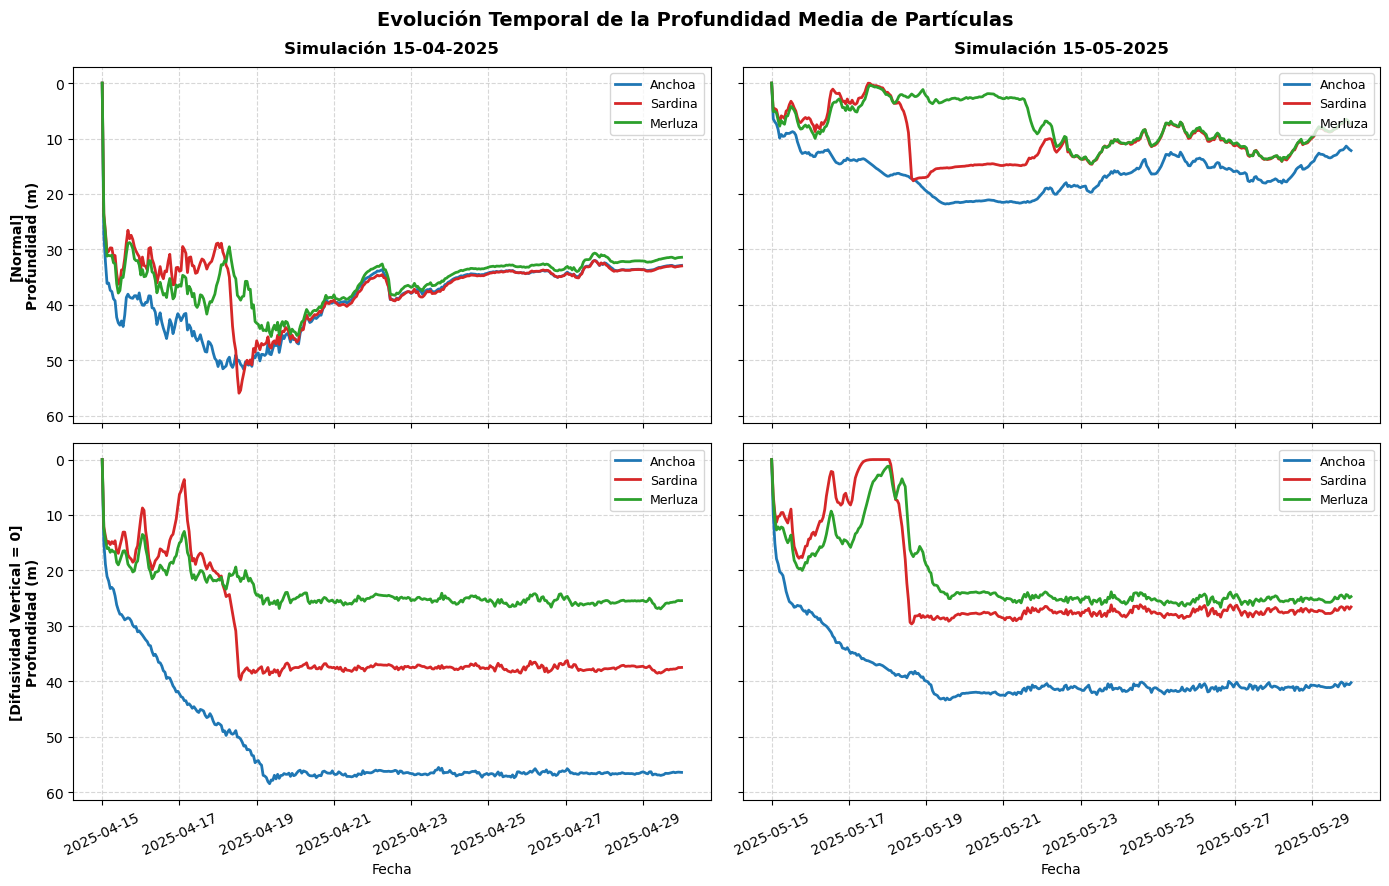

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definición de rutas
path_normal = "/home/adrian/Escritorio/conexion_cigala"
path_diff0  = "/home/adrian/Escritorio/conexion_cigala_2"

rutas = [path_normal, path_diff0]
fechas = ["20250415", "20250515"]
especies = ["anchovy", "sardine", "hake"]

# Estilos y etiquetas para cada especie
estilos_especies = {
    'anchovy': {'color': 'tab:blue',  'label': 'Anchoa'},
    'sardine': {'color': 'tab:red',   'label': 'Sardina'},
    'hake':    {'color': 'tab:green', 'label': 'Merluza'}
}

# Títulos descriptivos
titulos_filas = ["Normal", "Difusividad Vertical = 0"]
titulos_columnas = ["Simulación 15-04-2025", "Simulación 15-05-2025"]

# 2. Crear figura 2x2
# sharex='col' permite que las simulaciones de la misma fecha compartan el eje de tiempo
# sharey=True facilita la comparación directa de profundidades
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharex='col', sharey=True)

for row_idx, ruta in enumerate(rutas):
    for col_idx, fecha in enumerate(fechas):
        ax = axes[row_idx, col_idx]
        
        for esp in especies:
            nombre_archivo = f"Galicia_roms_{esp}_n_h_{fecha}.nc"
            filepath = os.path.join(ruta, nombre_archivo)
            
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    # Identificar la dimensión de partículas (la que no es 'time')
                    dim_particulas = [d for d in ds['z'].dims if d != 'time'][0]
                    
                    # Profundidad media positiva (depth = -z)
                    z_mean = ds['z'].mean(dim=dim_particulas)
                    profundidad_media = -z_mean.values
                    tiempos = ds['time'].values
                    
                    ax.plot(tiempos, profundidad_media, 
                            label=estilos_especies[esp]['label'], 
                            color=estilos_especies[esp]['color'], 
                            linewidth=2)
            else:
                print(f"Aviso: No se encontró {filepath}")

        # Formato de cada subplot
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc='upper right', fontsize=9)
        
        # Títulos de columnas (solo en la primera fila)
        if row_idx == 0:
            ax.set_title(titulos_columnas[col_idx], fontsize=12, fontweight='bold', pad=10)
            
        # Etiquetas de filas y eje Y (solo en la primera columna)
        if col_idx == 0:
            ax.set_ylabel(f"[{titulos_filas[row_idx]}]\nProfundidad (m)", fontsize=10, fontweight='bold')
            
        # Formato de fechas en el eje X para la última fila
        if row_idx == 1:
            ax.set_xlabel("Fecha", fontsize=10)
            ax.tick_params(axis='x', rotation=25)

# Invertir eje Y globalmente para que el 0 (superficie) quede arriba
axes[0, 0].invert_yaxis()

plt.suptitle("Evolución Temporal de la Profundidad Media de Partículas", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Guardar o mostrar
plt.savefig("comparativa_profundidades_2x2.png", dpi=300)
plt.show()

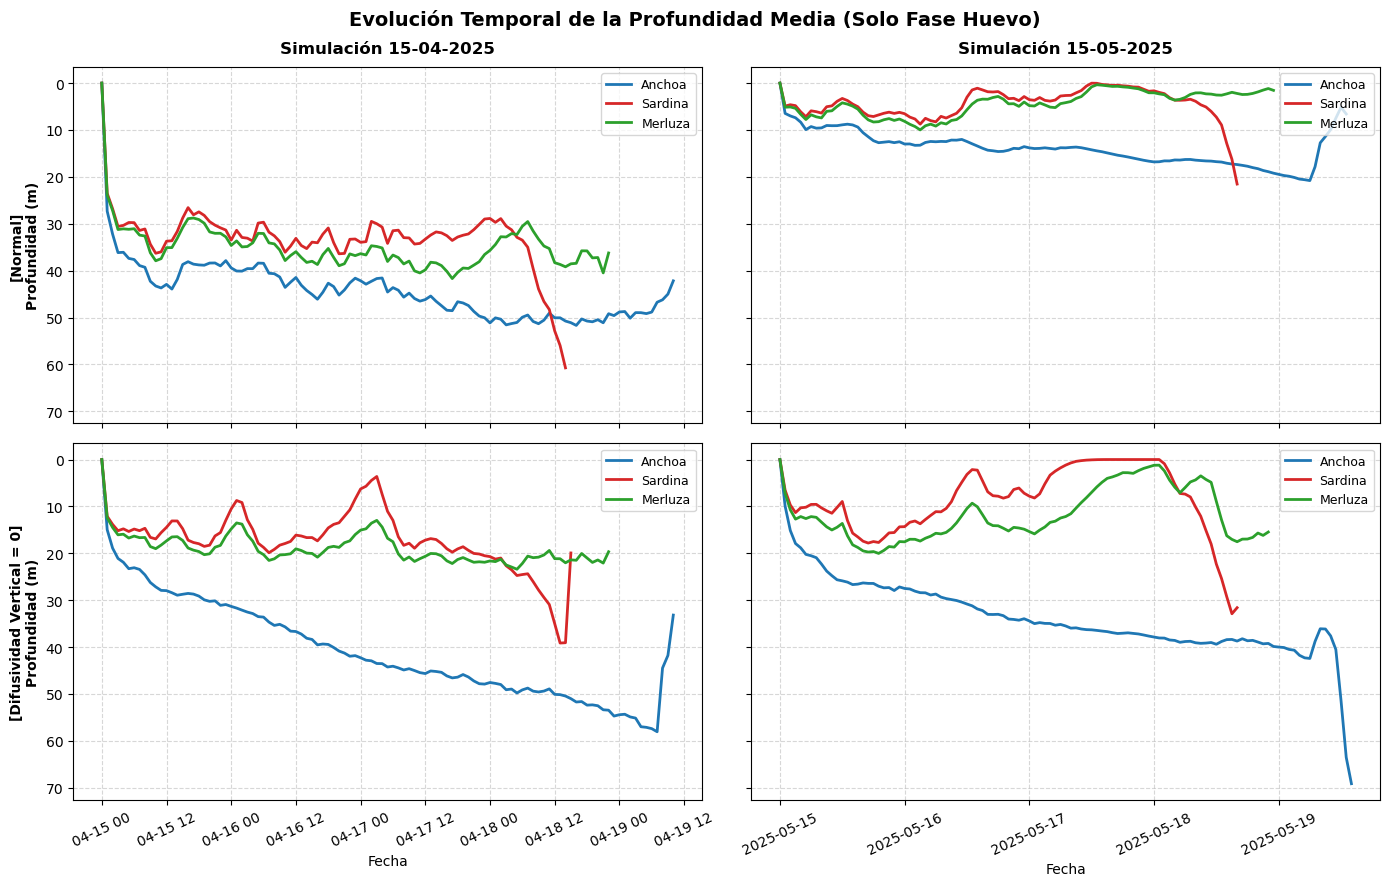

In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definición de rutas
path_normal = "/home/adrian/Escritorio/conexion_cigala"
path_diff0  = "/home/adrian/Escritorio/conexion_cigala_2"

rutas = [path_normal, path_diff0]
fechas = ["20250415", "20250515"]
especies = ["anchovy", "sardine", "hake"]

# Estilos y etiquetas para cada especie
estilos_especies = {
    'anchovy': {'color': 'tab:blue',  'label': 'Anchoa'},
    'sardine': {'color': 'tab:red',   'label': 'Sardina'},
    'hake':    {'color': 'tab:green', 'label': 'Merluza'}
}

titulos_filas = ["Normal", "Difusividad Vertical = 0"]
titulos_columnas = ["Simulación 15-04-2025", "Simulación 15-05-2025"]

# 2. Crear figura 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharex='col', sharey=True)

for row_idx, ruta in enumerate(rutas):
    for col_idx, fecha in enumerate(fechas):
        ax = axes[row_idx, col_idx]
        
        for esp in especies:
            nombre_archivo = f"Galicia_roms_{esp}_n_h_{fecha}.nc"
            filepath = os.path.join(ruta, nombre_archivo)
            
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    dim_particulas = [d for d in ds['z'].dims if d != 'time'][0]
                    
                    # 1. Crear máscara para la fase huevo
                    mask_huevo = ds['hatched'] < 1
                    
                    # 2. Aplicar máscara: los datos de larvas (hatched >= 1) se vuelven NaN
                    z_huevos = ds['z'].where(mask_huevo)
                    
                    # 3. Calcular la profundidad media ignorando los NaNs
                    z_mean = z_huevos.mean(dim=dim_particulas)
                    
                    # 4. Quedarnos solo con los tiempos donde todavía hay al menos un huevo
                    z_mean_valid = z_mean.dropna(dim='time')
                    
                    # Extraer variables finales para el plot
                    profundidad_media = -z_mean_valid.values
                    tiempos = z_mean_valid['time'].values
                    
                    ax.plot(tiempos, profundidad_media, 
                            label=estilos_especies[esp]['label'], 
                            color=estilos_especies[esp]['color'], 
                            linewidth=2)
            else:
                print(f"Aviso: No se encontró {filepath}")

        # Formato de cada subplot
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc='upper right', fontsize=9)
        
        if row_idx == 0:
            ax.set_title(titulos_columnas[col_idx], fontsize=12, fontweight='bold', pad=10)
            
        if col_idx == 0:
            ax.set_ylabel(f"[{titulos_filas[row_idx]}]\nProfundidad (m)", fontsize=10, fontweight='bold')
            
        if row_idx == 1:
            ax.set_xlabel("Fecha", fontsize=10)
            ax.tick_params(axis='x', rotation=25)

# Invertir eje Y globalmente para que el 0 quede arriba
axes[0, 0].invert_yaxis()

plt.suptitle("Evolución Temporal de la Profundidad Media (Solo Fase Huevo)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Guardar o mostrar
plt.savefig("comparativa_profundidades_huevos_2x2.png", dpi=300)
plt.show()

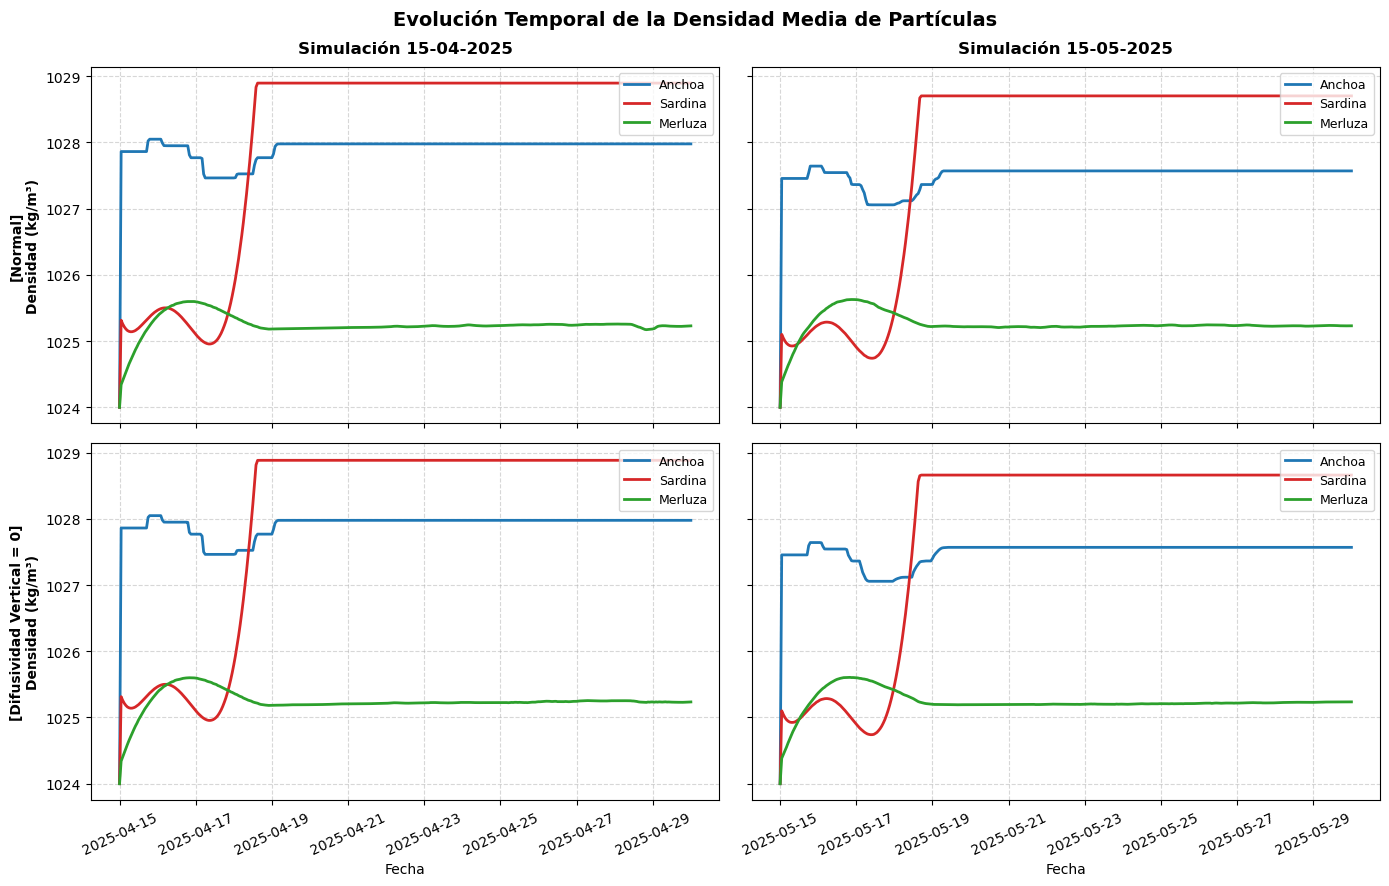

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definición de rutas
path_normal = "/home/adrian/Escritorio/conexion_cigala"
path_diff0  = "/home/adrian/Escritorio/conexion_cigala_2"

rutas = [path_normal, path_diff0]
fechas = ["20250415", "20250515"]
especies = ["anchovy", "sardine", "hake"]

# Estilos y etiquetas para cada especie
estilos_especies = {
    'anchovy': {'color': 'tab:blue',  'label': 'Anchoa'},
    'sardine': {'color': 'tab:red',   'label': 'Sardina'},
    'hake':    {'color': 'tab:green', 'label': 'Merluza'}
}

# Títulos descriptivos
titulos_filas = ["Normal", "Difusividad Vertical = 0"]
titulos_columnas = ["Simulación 15-04-2025", "Simulación 15-05-2025"]

# 2. Crear figura 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharex='col', sharey=True)

for row_idx, ruta in enumerate(rutas):
    for col_idx, fecha in enumerate(fechas):
        ax = axes[row_idx, col_idx]
        
        for esp in especies:
            nombre_archivo = f"Galicia_roms_{esp}_n_h_{fecha}.nc"
            filepath = os.path.join(ruta, nombre_archivo)
            
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    # Identificar la dimensión de partículas (la que no es 'time')
                    dim_particulas = [d for d in ds['egg_to_larvae_dens'].dims if d != 'time'][0]
                    
                    # Densidad media (kg/m³) por paso de tiempo
                    dens_mean = ds['egg_to_larvae_dens'].mean(dim=dim_particulas)
                    densidad_media = dens_mean.values
                    tiempos = ds['time'].values
                    
                    ax.plot(tiempos, densidad_media, 
                            label=estilos_especies[esp]['label'], 
                            color=estilos_especies[esp]['color'], 
                            linewidth=2)
            else:
                print(f"Aviso: No se encontró {filepath}")

        # Formato de cada subplot
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc='upper right', fontsize=9)
        
        # Títulos de columnas (solo en la primera fila)
        if row_idx == 0:
            ax.set_title(titulos_columnas[col_idx], fontsize=12, fontweight='bold', pad=10)
            
        # Etiquetas de filas y eje Y (solo en la primera columna)
        if col_idx == 0:
            ax.set_ylabel(f"[{titulos_filas[row_idx]}]\nDensidad (kg/m³)", fontsize=10, fontweight='bold')
            
        # Formato de fechas en el eje X para la última fila
        if row_idx == 1:
            ax.set_xlabel("Fecha", fontsize=10)
            ax.tick_params(axis='x', rotation=25)

# Nota: Se elimina el invert_yaxis() ya que la densidad aumenta hacia arriba de forma estándar

plt.suptitle("Evolución Temporal de la Densidad Media de Partículas", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Guardar o mostrar
plt.savefig("comparativa_densidades_2x2.png", dpi=300)
plt.show()

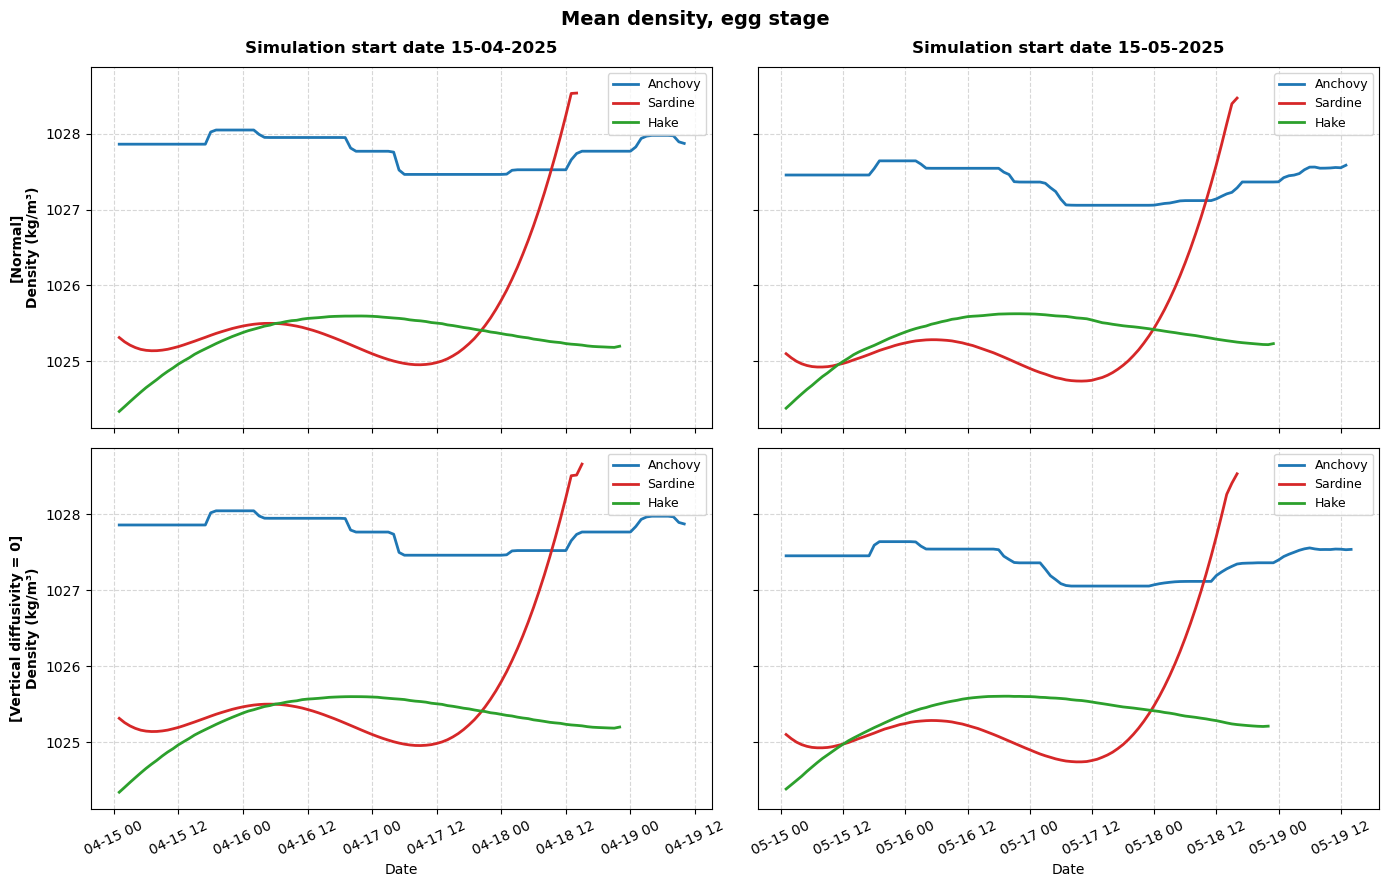

In [6]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definición de rutas
path_normal = "/home/adrian/Escritorio/conexion_cigala"
path_diff0  = "/home/adrian/Escritorio/conexion_cigala_2"

rutas = [path_normal, path_diff0]
fechas = ["20250415", "20250515"]
especies = ["anchovy", "sardine", "hake"]

# Estilos y etiquetas para cada especie
estilos_especies = {
    'anchovy': {'color': 'tab:blue',  'label': 'Anchovy'},
    'sardine': {'color': 'tab:red',   'label': 'Sardine'},
    'hake':    {'color': 'tab:green', 'label': 'Hake'}
}

titulos_filas = ["Normal", "Vertical diffusivity = 0"]
titulos_columnas = ["Simulation start date 15-04-2025", "Simulation start date 15-05-2025"]

# 2. Crear figura 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharex='col', sharey=True)

for row_idx, ruta in enumerate(rutas):
    for col_idx, fecha in enumerate(fechas):
        ax = axes[row_idx, col_idx]
        
        for esp in especies:
            nombre_archivo = f"Galicia_roms_{esp}_n_h_{fecha}.nc"
            filepath = os.path.join(ruta, nombre_archivo)
            
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    dim_particulas = [d for d in ds['egg_to_larvae_dens'].dims if d != 'time'][0]
                    
                    # 1. Crear máscara para la fase huevo (hatched < 1)
                    mask_huevo = ds['hatched'] < 1
                    
                    # 2. Aplicar máscara: las larvas (hatched >= 1) pasan a ser NaN
                    dens_huevos = ds['egg_to_larvae_dens'].where(mask_huevo)
                    
                    # 3. Calcular la densidad media de los huevos ignorando NaNs
                    dens_mean = dens_huevos.mean(dim=dim_particulas)
                    
                    # 4. Conservar solo los pasos de tiempo donde aún quedan huevos
                    dens_mean_valid = dens_mean.dropna(dim='time')
                    
                    # Extraer vectores omitiendo el primer valor ([1:])
                    if len(dens_mean_valid) > 1:
                        densidad_media = dens_mean_valid.values[1:]
                        tiempos = dens_mean_valid['time'].values[1:]
                        
                        ax.plot(tiempos, densidad_media, 
                                label=estilos_especies[esp]['label'], 
                                color=estilos_especies[esp]['color'], 
                                linewidth=2)
            else:
                print(f"Aviso: No se encontró {filepath}")

        # Formato de cada subplot
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc='upper right', fontsize=9)
        
        if row_idx == 0:
            ax.set_title(titulos_columnas[col_idx], fontsize=12, fontweight='bold', pad=10)
            
        if col_idx == 0:
            ax.set_ylabel(f"[{titulos_filas[row_idx]}]\nDensity (kg/m³)", fontsize=10, fontweight='bold')
            
        if row_idx == 1:
            ax.set_xlabel("Date", fontsize=10)
            ax.tick_params(axis='x', rotation=25)

plt.suptitle("Mean density, egg stage", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Guardar o mostrar
plt.savefig("comparativa_densidades_huevos_sin_inicio_2x2.png", dpi=300)
plt.show()

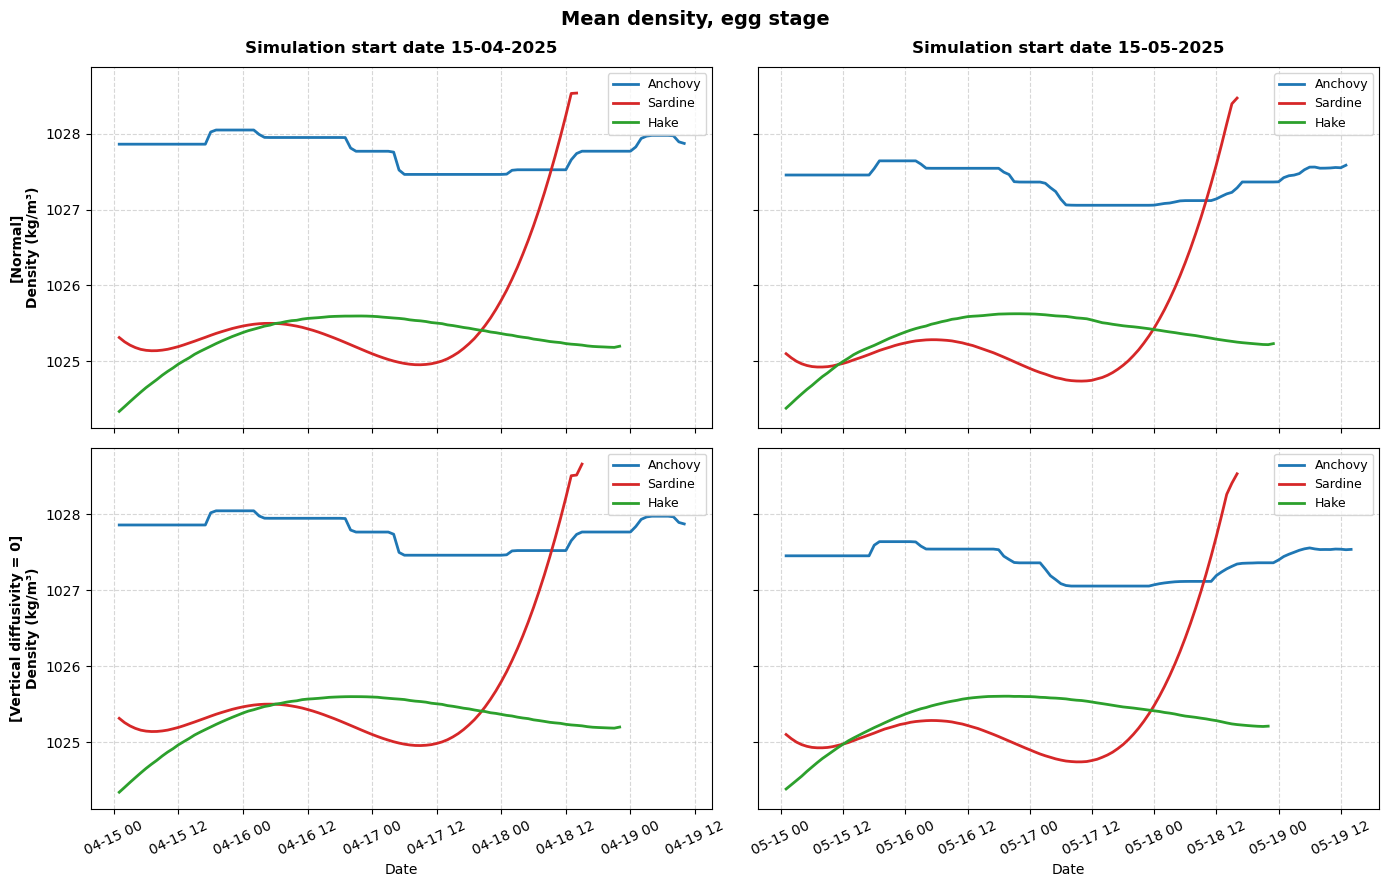

In [7]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path_normal = "/home/adrian/Escritorio/conexion_cigala"
path_diff0  = "/home/adrian/Escritorio/conexion_cigala_2"

rutas = [path_normal, path_diff0]
fechas = ["20250415", "20250515"]
especies = ["anchovy", "sardine", "hake"]

estilos_especies = {
    'anchovy': {'color': 'tab:blue',  'label': 'Anchovy'},
    'sardine': {'color': 'tab:red',   'label': 'Sardine'},
    'hake':    {'color': 'tab:green', 'label': 'Hake'}
}

titulos_filas = ["Normal", "Vertical diffusivity = 0"]
titulos_columnas = ["Simulation start date 15-04-2025", "Simulation start date 15-05-2025"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharex='col', sharey=True)

for row_idx, ruta in enumerate(rutas):
    for col_idx, fecha in enumerate(fechas):
        ax = axes[row_idx, col_idx]
        
        for esp in especies:
            nombre_archivo = f"Galicia_roms_{esp}_n_h_{fecha}.nc"
            filepath = os.path.join(ruta, nombre_archivo)
            
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    dim_particulas = [d for d in ds['egg_to_larvae_dens'].dims if d != 'time'][0]
                    mask_huevo = ds['hatched'] < 1
                    dens_huevos = ds['egg_to_larvae_dens'].where(mask_huevo)
                    dens_mean = dens_huevos.mean(dim=dim_particulas)
                    dens_mean_valid = dens_mean.dropna(dim='time')
                    
                    if len(dens_mean_valid) > 1:
                        densidad_media = dens_mean_valid.values[1:]
                        tiempos = dens_mean_valid['time'].values[1:]
                        
                        ax.plot(tiempos, densidad_media, 
                                label=estilos_especies[esp]['label'], 
                                color=estilos_especies[esp]['color'], 
                                linewidth=2)
            else:
                print(f"Aviso: No se encontró {filepath}")

        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc='upper right', fontsize=9)
        
        if row_idx == 0:
            ax.set_title(titulos_columnas[col_idx], fontsize=12, fontweight='bold', pad=10)
            
        if col_idx == 0:
            ax.set_ylabel(f"[{titulos_filas[row_idx]}]\nDensity (kg/m³)", fontsize=10, fontweight='bold')
            
        if row_idx == 1:
            ax.set_xlabel("Date", fontsize=10)
            ax.tick_params(axis='x', rotation=25)

plt.suptitle("Mean density, egg stage", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

plt.savefig("comparativa_densidades_huevos_sin_inicio_2x2.png", dpi=300)
plt.show()

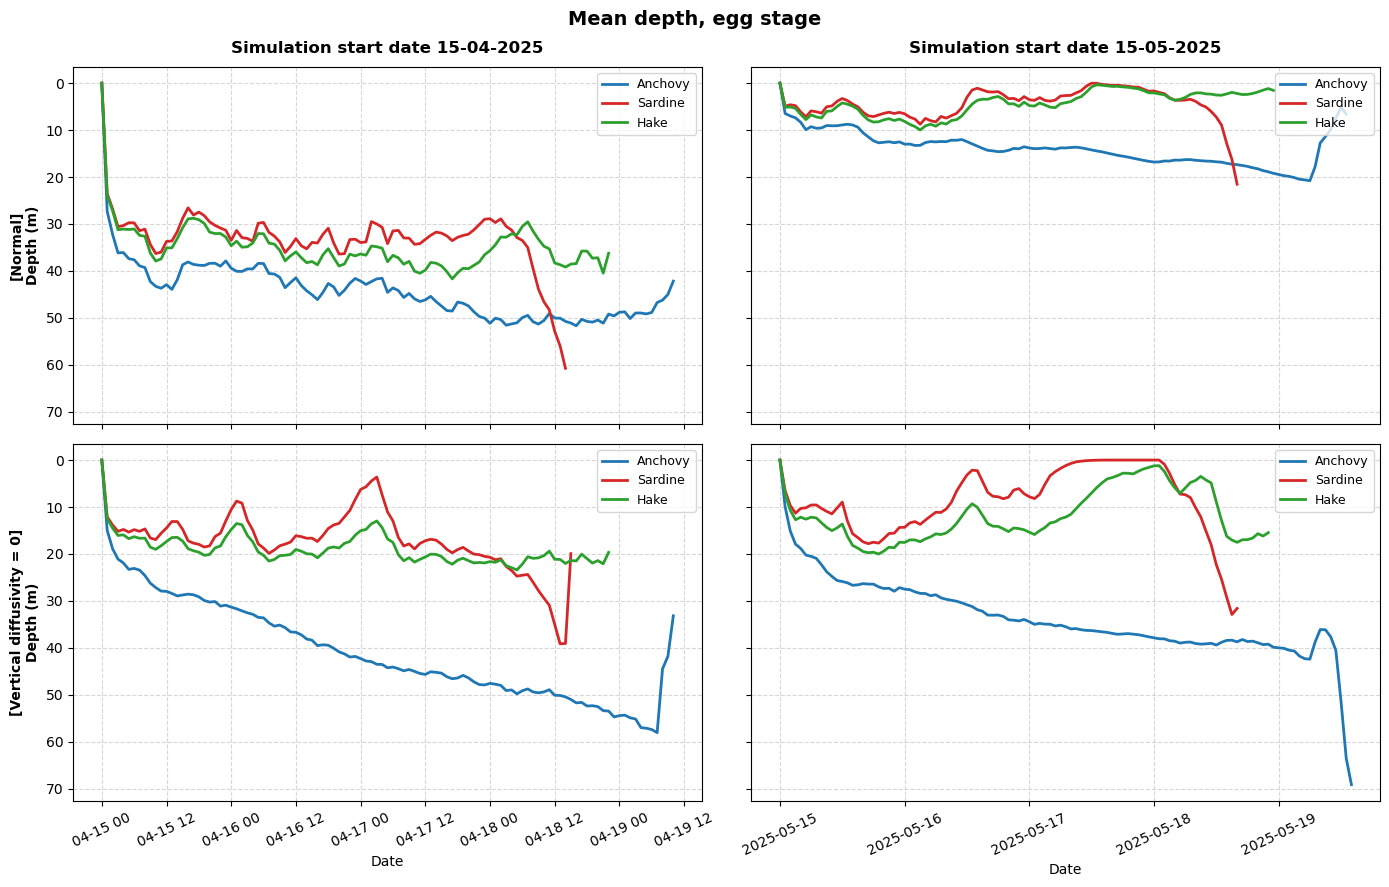

In [9]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path_normal = "/home/adrian/Escritorio/conexion_cigala"
path_diff0  = "/home/adrian/Escritorio/conexion_cigala_2"

rutas = [path_normal, path_diff0]
fechas = ["20250415", "20250515"]
especies = ["anchovy", "sardine", "hake"]

estilos_especies = {
    'anchovy': {'color': 'tab:blue',  'label': 'Anchovy'},
    'sardine': {'color': 'tab:red',   'label': 'Sardine'},
    'hake':    {'color': 'tab:green', 'label': 'Hake'}
}

titulos_filas = ["Normal", "Vertical diffusivity = 0"]
titulos_columnas = ["Simulation start date 15-04-2025", "Simulation start date 15-05-2025"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharex='col', sharey=True)

for row_idx, ruta in enumerate(rutas):
    for col_idx, fecha in enumerate(fechas):
        ax = axes[row_idx, col_idx]
        
        for esp in especies:
            nombre_archivo = f"Galicia_roms_{esp}_n_h_{fecha}.nc"
            filepath = os.path.join(ruta, nombre_archivo)
            
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    dim_particulas = [d for d in ds['z'].dims if d != 'time'][0]
                    mask_huevo = ds['hatched'] < 1
                    z_huevos = ds['z'].where(mask_huevo)
                    z_mean = z_huevos.mean(dim=dim_particulas)
                    z_mean_valid = z_mean.dropna(dim='time')
                    
                    if len(z_mean_valid) > 1:
                        profundidad_media = -z_mean_valid
                        tiempos = z_mean_valid['time']
                        
                        ax.plot(tiempos, profundidad_media, 
                                label=estilos_especies[esp]['label'], 
                                color=estilos_especies[esp]['color'], 
                                linewidth=2)
            else:
                print(f"Aviso: No se encontró {filepath}")

        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc='upper right', fontsize=9)
        
        if row_idx == 0:
            ax.set_title(titulos_columnas[col_idx], fontsize=12, fontweight='bold', pad=10)
            
        if col_idx == 0:
            ax.set_ylabel(f"[{titulos_filas[row_idx]}]\nDepth (m)", fontsize=10, fontweight='bold')
            
        if row_idx == 1:
            ax.set_xlabel("Date", fontsize=10)
            ax.tick_params(axis='x', rotation=25)

axes[0, 0].invert_yaxis()

plt.suptitle("Mean depth, egg stage", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

plt.savefig("comparativa_profundidades_huevos_sin_inicio_2x2.png", dpi=300)
plt.show()

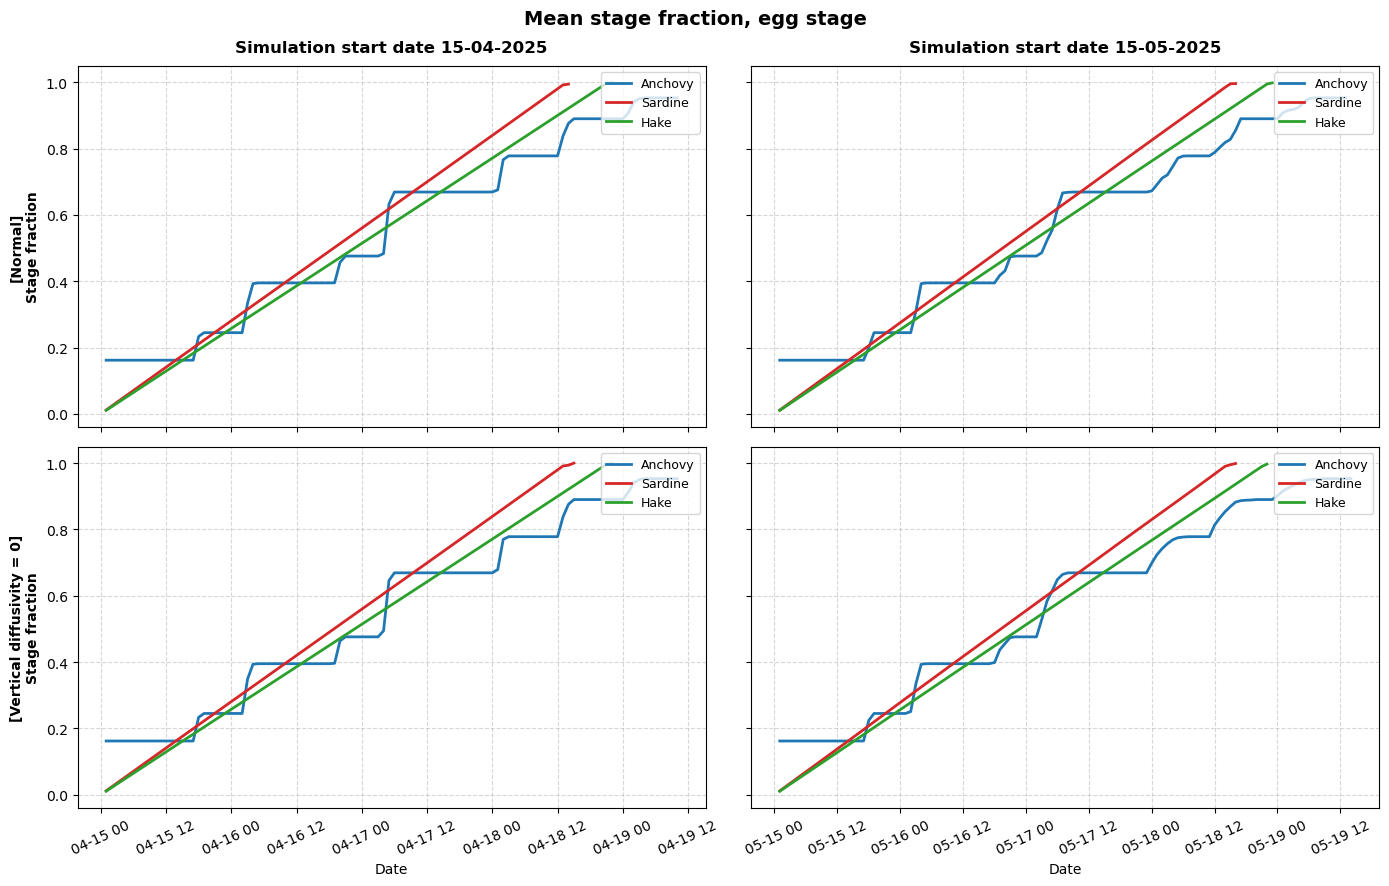

In [10]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path_normal = "/home/adrian/Escritorio/conexion_cigala"
path_diff0  = "/home/adrian/Escritorio/conexion_cigala_2"

rutas = [path_normal, path_diff0]
fechas = ["20250415", "20250515"]
especies = ["anchovy", "sardine", "hake"]

estilos_especies = {
    'anchovy': {'color': 'tab:blue',  'label': 'Anchovy'},
    'sardine': {'color': 'tab:red',   'label': 'Sardine'},
    'hake':    {'color': 'tab:green', 'label': 'Hake'}
}

titulos_filas = ["Normal", "Vertical diffusivity = 0"]
titulos_columnas = ["Simulation start date 15-04-2025", "Simulation start date 15-05-2025"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharex='col', sharey=True)

for row_idx, ruta in enumerate(rutas):
    for col_idx, fecha in enumerate(fechas):
        ax = axes[row_idx, col_idx]
        
        for esp in especies:
            nombre_archivo = f"Galicia_roms_{esp}_n_h_{fecha}.nc"
            filepath = os.path.join(ruta, nombre_archivo)
            
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    dim_particulas = [d for d in ds['stage_fraction'].dims if d != 'time'][0]
                    mask_huevo = ds['hatched'] < 1
                    stage_huevos = ds['stage_fraction'].where(mask_huevo)
                    stage_mean = stage_huevos.mean(dim=dim_particulas)
                    stage_mean_valid = stage_mean.dropna(dim='time')
                    
                    if len(stage_mean_valid) > 1:
                        stage_media = stage_mean_valid.values[1:]
                        tiempos = stage_mean_valid['time'].values[1:]
                        
                        ax.plot(tiempos, stage_media, 
                                label=estilos_especies[esp]['label'], 
                                color=estilos_especies[esp]['color'], 
                                linewidth=2)
            else:
                print(f"Aviso: No se encontró {filepath}")

        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc='upper right', fontsize=9)
        
        if row_idx == 0:
            ax.set_title(titulos_columnas[col_idx], fontsize=12, fontweight='bold', pad=10)
            
        if col_idx == 0:
            ax.set_ylabel(f"[{titulos_filas[row_idx]}]\nStage fraction", fontsize=10, fontweight='bold')
            
        if row_idx == 1:
            ax.set_xlabel("Date", fontsize=10)
            ax.tick_params(axis='x', rotation=25)

plt.suptitle("Mean stage fraction, egg stage", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

plt.savefig("comparativa_stage_fraction_huevos_sin_inicio_2x2.png", dpi=300)
plt.show()

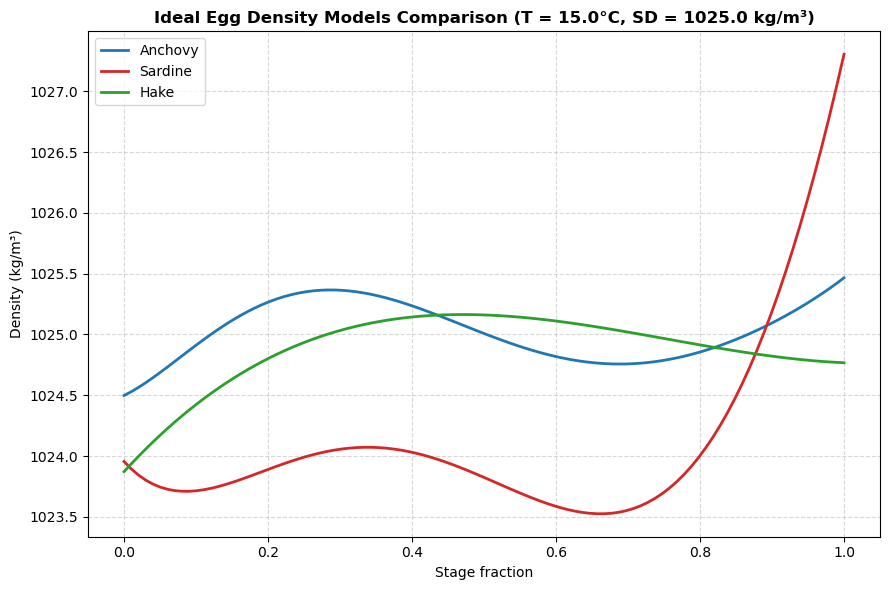

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import gsw

stage_fraction = np.linspace(0, 1, 100)
T = 15.0
SD = 1025.0

coef_sardine = [0.0012, -1.8528, 15.507, -41.1312, 40.5289, -12.1166, 0.0]
poly_sardine = np.polynomial.Polynomial(coef_sardine)
dens_sardine = 3.58 * poly_sardine(stage_fraction) + 0.78797 * (SD - 1000) + 1004.2519

coef_anchovy = [0.0, 2.908, 23.747, -136.860, 241.037, -179.746, 49.882]
poly_anchovy = np.polynomial.Polynomial(coef_anchovy)
dens_anchovy = poly_anchovy(stage_fraction) + 1.4906 * (SD - 1000) + 987.2325

coef_hake_sal = [32.40454384, 8.50113011, -13.13527379, 5.8108654]
poly_hake_sal = np.polynomial.Polynomial(coef_hake_sal)
sal_hake = poly_hake_sal(stage_fraction)

dens_hake = gsw.rho(sal_hake, T, 0)

plt.figure(figsize=(9, 6))

plt.plot(stage_fraction, dens_anchovy, color='tab:blue', label='Anchovy', linewidth=2)
plt.plot(stage_fraction, dens_sardine, color='tab:red', label='Sardine', linewidth=2)
plt.plot(stage_fraction, dens_hake, color='tab:green', label='Hake', linewidth=2)

plt.title(f"Ideal Egg Density Models Comparison (T = {T}°C, SD = {SD} kg/m³)", fontsize=12, fontweight='bold')
plt.xlabel("Stage fraction", fontsize=10)
plt.ylabel("Density (kg/m³)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig("comparativa_modelos_densidad_ideal.png", dpi=300)
plt.show()

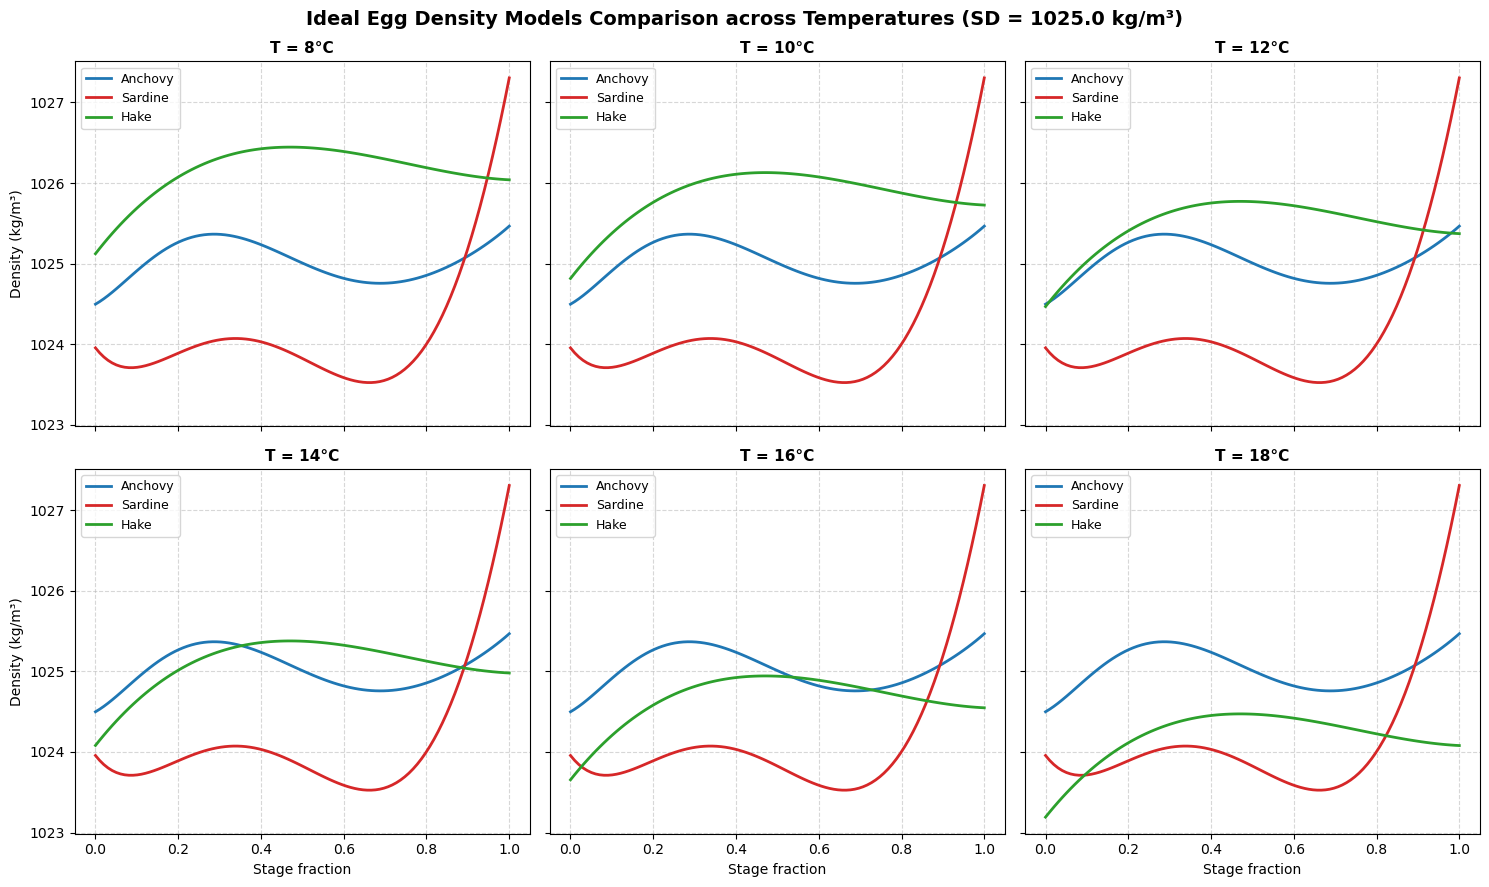

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gsw

stage_fraction = np.linspace(0, 1, 100)
temperaturas = range(8, 19, 2)
SD = 1025.0

coef_sardine = [0.0012, -1.8528, 15.507, -41.1312, 40.5289, -12.1166, 0.0]
poly_sardine = np.polynomial.Polynomial(coef_sardine)
dens_sardine = 3.58 * poly_sardine(stage_fraction) + 0.78797 * (SD - 1000) + 1004.2519

coef_anchovy = [0.0, 2.908, 23.747, -136.860, 241.037, -179.746, 49.882]
poly_anchovy = np.polynomial.Polynomial(coef_anchovy)
dens_anchovy = poly_anchovy(stage_fraction) + 1.4906 * (SD - 1000) + 987.2325

coef_hake_sal = [32.40454384, 8.50113011, -13.13527379, 5.8108654]
poly_hake_sal = np.polynomial.Polynomial(coef_hake_sal)
sal_hake = poly_hake_sal(stage_fraction)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

for idx, T in enumerate(temperaturas):
    ax = axes_flat[idx]
    
    dens_hake = gsw.rho(sal_hake, T, 0)

    ax.plot(stage_fraction, dens_anchovy, color='tab:blue', label='Anchovy', linewidth=2)
    ax.plot(stage_fraction, dens_sardine, color='tab:red', label='Sardine', linewidth=2)
    ax.plot(stage_fraction, dens_hake, color='tab:green', label='Hake', linewidth=2)

    ax.set_title(f"T = {T}°C", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc='best', fontsize=9)

for ax in axes[1, :]:
    ax.set_xlabel("Stage fraction", fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel("Density (kg/m³)", fontsize=10)

plt.suptitle(f"Ideal Egg Density Models Comparison across Temperatures (Spawning Density = {SD} kg/m³)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("comparativa_modelos_densidad_multi_T.png", dpi=300)
plt.show()